In [1]:
# Summary notes on Orchestrator-Worker Workflow with LangGraph

"""
Orchestrator-Worker Workflow with LangGraph:

- **Orchestrator**: The orchestrator is responsible for managing and coordinating the overall workflow. It receives tasks, breaks them down, assigns them to workers, and aggregates results.
- **Worker**: Workers are independent units that execute specific tasks assigned by the orchestrator. They process data, perform computations, or interact with external systems.

**LangGraph**:
- LangGraph is a framework for building stateful, multi-agent workflows using language models.
- It allows you to define workflows as graphs, where nodes represent agents (or workers) and edges represent transitions or message passing.
- The orchestrator can be implemented as a central node that routes tasks to worker nodes based on workflow logic.
- Workers can be specialized agents (e.g., summarizer, retriever, generator) that perform distinct functions.
- LangGraph handles message passing, state management, and coordination between orchestrator and workers.

**Typical Workflow**:
1. The orchestrator receives an input or task.
2. It determines which worker(s) should handle the task based on the workflow graph.
3. The orchestrator sends the task to the appropriate worker(s).
4. Workers process the task and return results to the orchestrator.
5. The orchestrator may aggregate, post-process, or route results to other workers as needed.
6. The final output is produced and returned.

**Benefits**:
- Modular and scalable workflow design.
- Clear separation of responsibilities between orchestrator and workers.
- Easy to extend or modify workflows by updating the graph structure.
- Supports complex, multi-step, and multi-agent workflows.

**Use Cases**:
- Multi-step reasoning tasks
- Document processing pipelines
- Conversational agents with specialized skills
- Data enrichment and transformation workflows
"""

'\nOrchestrator-Worker Workflow with LangGraph:\n\n- **Orchestrator**: The orchestrator is responsible for managing and coordinating the overall workflow. It receives tasks, breaks them down, assigns them to workers, and aggregates results.\n- **Worker**: Workers are independent units that execute specific tasks assigned by the orchestrator. They process data, perform computations, or interact with external systems.\n\n**LangGraph**:\n- LangGraph is a framework for building stateful, multi-agent workflows using language models.\n- It allows you to define workflows as graphs, where nodes represent agents (or workers) and edges represent transitions or message passing.\n- The orchestrator can be implemented as a central node that routes tasks to worker nodes based on workflow logic.\n- Workers can be specialized agents (e.g., summarizer, retriever, generator) that perform distinct functions.\n- LangGraph handles message passing, state management, and coordination between orchestrator and

In [27]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("AZURE_OPENAI_API_KEY")
os.environ["OPENAI_ENDPOINT"] = os.getenv("AZURE_OPENAI_ENDPOINT")
os.environ["OPENAI_API_VERSION"] = "2024-12-01-preview"
os.environ["OPENAI_DEPLOYMENT_NAME"] = "gpt-4o"
os.environ["OPENAI_MODEL"] = "gpt-4o"

open_api_key = os.getenv("AZURE_OPENAI_API_KEY")
if os.getenv("AZURE_OPENAI_API_KEY"):
    print(f"Azure Open API Key loaded: {open_api_key[:10]}...{open_api_key[-4:]}")
    print(f"Model: {os.getenv('OPENAI_MODEL')}")
    os.environ["OPENAI_API_KEY"] = open_api_key
else:
    print("Azure API Key not found in environment variables")
    print("Available environment variables with 'Azure':", [k for k in os.environ.keys() if 'Azure' in k.upper()])



Azure Open API Key loaded: 1Sttw3VbMy...EzVq
Model: gpt-4o


In [28]:
from langchain_openai import AzureChatOpenAI
from langchain.schema import HumanMessage, SystemMessage

# Create Azure ChatOpenAI instance
llm = AzureChatOpenAI(
    azure_deployment=os.getenv("OPENAI_DEPLOYMENT_NAME"),   
    api_version=os.getenv("OPENAI_API_VERSION"),            
    azure_endpoint=os.getenv("OPENAI_ENDPOINT"),           
    api_key=os.getenv("OPENAI_API_KEY")
)

print(f"Created Azure ChatOpenAI: {llm}")
llm.invoke("hello")

Created Azure ChatOpenAI: client=<openai.resources.chat.completions.completions.Completions object at 0x7fed9c5dda00> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7fed9c5dfec0> root_client=<openai.lib.azure.AzureOpenAI object at 0x7fed9c5dcd10> root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x7fed9c5dd670> model_kwargs={} openai_api_key=SecretStr('**********') disabled_params={'parallel_tool_calls': None} azure_endpoint='https://zama-roadmap-to-aiml.openai.azure.com/' deployment_name='gpt-4o' openai_api_version='2024-12-01-preview' openai_api_type='azure'


AIMessage(content='Hello! How can I assist you today? 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 8, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_ee1d74bde0', 'id': 'chatcmpl-BoDQlHDCIbC97AALb1cSfGfSWeHEu', 'service_tier': None, 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'filtered': False, 'detected': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 

In [29]:
from typing import Annotated, List
import operator
from typing_extensions import Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
from typing_extensions import TypedDict


class Section(BaseModel):
    name: str = Field(description="Name of the section for report")
    description: str = Field(description="Description of the section for report")

class Sections(BaseModel):
    sections: List[Section] = Field(description="List of sections for report")

planner = llm.with_structured_output(Sections)
planner


RunnableBinding(bound=AzureChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x7fed9c5dda00>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7fed9c5dfec0>, root_client=<openai.lib.azure.AzureOpenAI object at 0x7fed9c5dcd10>, root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x7fed9c5dd670>, model_kwargs={}, openai_api_key=SecretStr('**********'), disabled_params={'parallel_tool_calls': None}, azure_endpoint='https://zama-roadmap-to-aiml.openai.azure.com/', deployment_name='gpt-4o', openai_api_version='2024-12-01-preview', openai_api_type='azure'), kwargs={'response_format': <class '__main__.Sections'>, 'ls_structured_output_format': {'kwargs': {'method': 'json_schema', 'strict': None}, 'schema': {'type': 'function', 'function': {'name': 'Sections', 'description': '', 'parameters': {'properties': {'sections': {'description': 'List of sections for report', 'items': {'properties': {'name': {'descri

In [30]:
# create workers dynamically
from langgraph.constants import Send

class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections: Annotated[
        list, operator.add
    ]
    final_report: str

class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


In [44]:
# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""
    report_sections = planner.invoke(
        SystemMessage(content="Generate a plan for the report."),
        HumanMessage(content=f"Create a report on {state['topic']}")
    )
    print("Report sections:", report_sections)

    return {"sections": report_sections.sections}

def llm_call(state: WorkerState):
    """LLM worker that generates content for a section"""
    section = state["section"]
    print(f"Generating content for section: {section.name}")
    
    response = llm.invoke(
        [
            SystemMessage(
                content=f"Write a report section following the name and descrition provided: {section.name} - {section.description}"
            ),
            HumanMessage(
                content=f"Section name: {section.name} and Description: {section.descriiption}"
            )
        ]
    )
    
    return {"completed_sections": [section.content]}

def assign_workers(state: State):
    """Assign workers to each section"""

    return [Send("llm_call", {"section": s}) for s in state["sections"]]

def synthesizer(state: State):
    """Synthesizer that combines all sections into a final report"""
    print("Combining sections into final report")
    final_report = "\n\n-------\n\n".join([s.content for s in state["completed_sections"]])
    
    return {"final_report": final_report}

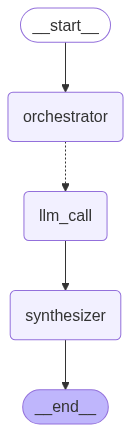

In [45]:
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

orchestrator_graph = StateGraph(State)

#Add nodes
orchestrator_graph.add_node("orchestrator", orchestrator)
orchestrator_graph.add_node("llm_call", llm_call)
orchestrator_graph.add_node("synthesizer", synthesizer)

# Add edges
orchestrator_graph.add_edge(START, "orchestrator")
orchestrator_graph.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_graph.add_edge("llm_call", "synthesizer")
orchestrator_graph.add_edge("synthesizer", END)

orchestrator_workflow = orchestrator_graph.compile()

display(Image(orchestrator_workflow.get_graph().draw_mermaid_png()))


In [48]:
# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""
    report_sections = planner.invoke([
        SystemMessage(content="Generate a plan for the report."),
        HumanMessage(content=f"Create a report on {state['topic']}")
    ])
    print("Report sections:", report_sections)

    return {"sections": report_sections.sections}

def llm_call(state: WorkerState):
    """LLM worker that generates content for a section"""
    section = state["section"]
    print(f"Generating content for section: {section.name}")
    
    response = llm.invoke([
        SystemMessage(
            content=f"Write a report section following the name and description provided: {section.name} - {section.description}"
        ),
        HumanMessage(
            content=f"Section name: {section.name} and Description: {section.description}"
        )
    ])
    
    return {"completed_sections": [response.content]}

def assign_workers(state: State):
    """Assign workers to each section"""
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

def synthesizer(state: State):
    """Synthesizer that combines all sections into a final report"""
    print("Combining sections into final report")
    final_report = "\n\n-------\n\n".join(state["completed_sections"])
    
    return {"final_report": final_report}

# First, we need to rebuild the workflow with the corrected functions
orchestrator_graph = StateGraph(State)

# Add nodes
orchestrator_graph.add_node("orchestrator", orchestrator)
orchestrator_graph.add_node("llm_call", llm_call)
orchestrator_graph.add_node("synthesizer", synthesizer)

# Add edges
orchestrator_graph.add_edge(START, "orchestrator")
orchestrator_graph.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_graph.add_edge("llm_call", "synthesizer")
orchestrator_graph.add_edge("synthesizer", END)

orchestrator_workflow = orchestrator_graph.compile()

# Now invoke the workflow
state = orchestrator_workflow.invoke({"topic": "Create a report on Agentic AI RAGs"})
print("Final state:", state)

from IPython.display import Markdown
Markdown(state["final_report"])

Report sections: sections=[Section(name='Introduction', description='Introduce the topic of Agentic AI RAGs and provide background information.'), Section(name='Overview of Agentic AI', description='Define Agentic AI and discuss its relevance in current AI discourse.'), Section(name='Knowledge Systems and RAGs', description='Explain the architecture and motivation behind retrieval-augmented generation (RAGs).'), Section(name='Agentic Capabilities in RAGs', description='Explore how RAG models incorporate agentic characteristics.'), Section(name='Applications of Agentic AI RAGs', description='Discuss practical applications and use cases of these systems.'), Section(name='Challenges and Considerations', description='Examine the ethical and technical challenges associated with Agentic AI and RAGs.'), Section(name='Conclusion', description='Summarize key points and suggest future directions or recommendations.')]
Generating content for section: Introduction
Generating content for section: K

### Introduction

In recent years, the integration of artificial intelligence (AI) into multifaceted domains has transformed how humans access, process, and utilize information. Among these advancements, *Agentic AI Retrieval-Augmented Generative Systems (Agentic AI RAGs)* represent a powerful paradigm at the intersection of generative AI and retrieval-based systems. These systems combine the ability of generative AI to produce contextually relevant content with retrieval mechanisms that draw from vast external datasets or knowledge repositories to enhance factual accuracy, interpretability, and domain specificity. The result is a unified framework designed to perform complex tasks by autonomously gathering, synthesizing, and generating information.

The concept of agentic AI refers to systems endowed with a degree of autonomy and decision-making capabilities, enabling them to adapt dynamically to the user’s goals and the contextual environment in which they operate. When paired with retrieval-augmented generation (RAG), this agentic capacity is further enriched by the system’s ability to retrieve the most pertinent knowledge in real time to inform its generative output. This hybrid approach addresses several limitations of stand-alone generative models, such as hallucinations (i.e., the generation of confident but incorrect information) and outdated knowledge constraints, which are common in static, pre-trained systems.

Agentic AI RAGs are particularly relevant in applications requiring nuanced reasoning, iterative learning, and highly targeted knowledge synthesis. For example, they are instrumental in research assistance, customer support, medical diagnostics, and legal advisory contexts, where precision and adaptability are critical. Beyond specific applications, these systems represent a broader technological shift toward personalized, interactive, and self-directed AI agents.

This report delves into the foundational principles, architecture, and implications of Agentic AI RAGs. By exploring their functionality, potential use cases, and challenges, we aim to provide insight into their role as an emerging force in the evolving landscape of artificial intelligence.

-------

# Overview of Agentic AI

Agentic AI refers to artificial intelligence systems that exhibit a degree of autonomy, decision-making capability, and goal-oriented behavior resembling that of a human or independent agent. These systems are designed to analyze their environment, make contextually informed decisions, and execute actions without requiring constant guidance from human operators. The term "agentic" emphasizes the system's self-directed nature, where it operates with a sense of purpose or intent aligned with objectives set by developers, users, or the system itself.

Agentic AI systems often include components such as natural language understanding, situational awareness, scalable memory, and the ability to adapt dynamically to changing conditions. They may be employed in a variety of domains, from autonomous vehicles navigating complex traffic scenarios to personal assistants like ChatGPT, which anticipate user needs and provide relevant information or solutions. Crucially, while agentic AI systems may appear to demonstrate intent or agency, they do not possess intrinsic consciousness or free will; their goal-directed capabilities are still fundamentally derived from algorithmic programming and training data.

### Relevance in Current AI Discourse

Agentic AI occupies a central position in the contemporary conversation around artificial intelligence due to its transformative potential and the ethical considerations it raises. With rapid advancements in machine learning, neural networks, and computational power, AI systems are increasingly capable of functioning autonomously in high-stakes environments, from healthcare diagnostics to financial decision-making and even governance support. This emerging autonomy highlights several critical areas for discourse:

1. **Innovation and Productivity**: Agentic AI is lauded for its potential to amplify productivity across industries. By automating complex tasks, providing real-time insights, and adapting to unforeseen circumstances, agentic AI systems can revolutionize workflows and enable progress at unprecedented speed. For instance, in logistics, agentic AI can optimize supply chain management by autonomously rerouting shipments in response to disruptions.

2. **Ethical and Safety Concerns**: The autonomy exhibited by agentic AI has sparked vigorous debate over issues such as accountability, transparency, and risk management. How do we ensure that these systems align with human values, especially in scenarios where their decisions have significant social or ethical implications? The 2023 debate around autonomous weapons and the ethical use of AI in warfare exemplifies the urgent need to govern agentic systems responsibly.

3. **Human-AI Collaboration**: Agentic AI also raises questions about the evolving nature of human-AI relationships. How do humans and machines collaborate effectively without undermining human agency? Advocates emphasize the importance of maintaining human oversight and building systems that enhance, rather than replace, human decision-making capabilities.

4. **Existential and Long-Term Risks**: Some experts argue that agentic AI could eventually pose existential threats if its autonomy becomes sufficiently advanced. While such outcomes may lie far in the future, the discourse emphasizes proactive research into AI alignment and control mechanisms to address risks before they manifest.

5. **Regulatory Challenges**: Policymakers and regulatory bodies face the complex task of crafting legal frameworks that govern the deployment and behavior of agentic systems. These challenges include defining liability when agentic AI causes harm and balancing innovation with societal safeguards.

In sum, agentic AI is a double-edged sword—while its potential to drive progress and efficiency is immense, its autonomous nature demands meticulous oversight to prevent unintended consequences. Its increasing prevalence ensures that discussions about its role, design, and governance remain at the forefront of the AI discourse, with far-reaching implications for technology, ethics, and society. As researchers, governments, and organizations collaborate to shape the AI landscape, the development of responsible agentic AI systems is likely to remain one of the defining challenges of the 21st century.

-------

# Knowledge Systems and RAGs

Retrieval-Augmented Generation (RAG) represents a paradigm shift in how AI systems approach tasks that require complex reasoning, information synthesis, and dynamic interaction with external knowledge. This architecture combines the strengths of large language models (LLMs) in natural language generation with the precision and adaptability of external information retrieval systems. At its core, RAG integrates a foundational generative model with real-time access to a vast corpus of knowledge, enabling it to produce more accurate, explainable, and context-relevant output. Below, we detail the motivation for RAGs and unpack their architectural foundations.

## Motivation Behind RAGs

Traditional language models, trained on extensive but static datasets, demonstrate remarkable ability in generating coherent and contextually appropriate text. However, they are inherently limited in several key areas:
1. **Knowledge Staleness**: LLMs carry the risk of outdated or incomplete knowledge as their training data cuts off at a specific point in time. They lack the ability to incorporate new or dynamic information after training is complete.
2. **Parameter Memory Constraints**: Storing all potential facts and knowledge directly in a model's parameters becomes infeasible as the scope and scale of information grow exponentially. Such reliance leads to increased computational costs and diminished efficiency.
3. **Explainability and Traceability**: Purely generative models often function as "black boxes" when providing information, offering no transparency or explicit citation of sources, which can undermine trust in their output.
4. **Fluidity of Information**: Many tasks, such as answering queries about current events, conducting specialized research, or navigating complex, domain-specific knowledge, require access to constantly evolving datasets or real-time retrieval of information, which static models cannot provide.

RAG systems address these challenges by treating knowledge retrieval and language generation as distinct yet interconnected components. By combining retrieval capabilities with generative capacities, they bridge the gap between static knowledge representation and dynamic, context-responsive AI systems.

## Architecture of RAGs

The RAG architecture is typically composed of two key components: a **retriever module** and a **generator module**, which work in tandem to enhance both the relevance and reliability of generated outputs.

### 1. Retriever Module
The retriever is responsible for identifying and extracting relevant pieces of information from an external knowledge source (e.g., a database, document corpus, or online API). It fulfills the role of dynamically augmenting the model's understanding with real-time or domain-specific data. The retriever often employs specialized techniques to ensure information relevancy:
   - **Embedding-based Retrieval**: Using dense embeddings generated by deep learning models (e.g., sentence embeddings) to represent both queries and knowledge documents in a shared vector space, enabling efficient similarity searches.
   - **Search Engines or APIs**: Integration with traditional search engines (e.g., Elasticsearch) or APIs for scalable data access.

Retrieval helps the system focus its attention on the most pertinent knowledge fragments rather than relying solely on the generative model's training data. This reduces memory overhead and opens the door to faster updates as new information is added to the knowledge base.

### 2. Generator Module
The generator is the large language model that processes the retrieved information and crafts it into human-readable, coherent responses. It uses:
   - **Context Awareness**: The retrieved content is combined with the input query to form a richer input prompt, ensuring that the generator has sufficient context.
   - **Reasoning Skills**: The generator synthesizes the retrieved knowledge and applies its own language modeling capabilities to create natural, contextually aware, and fluent responses.

In practice, modern pre-trained language models like OpenAI's GPT or Google's T5 can serve as the generator, leveraging their immense capacity for nuanced language understanding.

### 3. Interaction Between Retriever and Generator
The retriever and generator modules operate in a feedback loop:
   - **Query Reformulation**: The generator can use its initial understanding of the task to guide a refined search query for the retriever, iteratively improving the relevance of the retrieved documents.
   - **Compression and Fusion**: Retrieved documents are filtered and summarized into concise snippets before being passed to the generator, optimizing the final output's length and focus.

### 4. Knowledge Database
The retriever accesses a massive external knowledge database tailored to the application's demands:
   - Static corpora, including books or academic papers.
   - Dynamic sources that are regularly updated (e.g., web content, real-time APIs).
   - Structured data sources, like knowledge graphs or SQL databases.

The modularity of RAGs makes it easy to enhance the underlying database without retraining the core language model, which is both cost-effective and flexible.

### Additional Considerations
- **Memory-Augmented Variants**: Some RAG implementations leverage memory-augmented neural networks, which maintain a cache of recently retrieved and contextualized information, further enhancing the model's long-term knowledge retention.
- **Optimization Techniques**: Fine-tuning can align retrieval mechanisms with the generator's requirements, improving the harmony between retrieved snippets and generated text.
- **Explainability Features**: By including references to retrieved knowledge in generated outputs, RAGs increase transparency, enabling users to trace responses back to source material.

## Advantages of the RAG Framework

RAGs offer several compelling benefits:
1. **Real-Time and Specialized Knowledge**: By combining retrieval with generation, RAGs can handle tasks that demand up-to-date or highly specialized knowledge without requiring exhaustive retraining.
2. **Cost-Efficiency**: Generative models can remain smaller and more cost-effective since they delegate vast knowledge storage to external databases or retrieval methods.
3. **Scalability**: As the knowledge base grows, RAG systems scale naturally, enabling seamless integration of additional sources without modifying the model's architecture.
4. **Improved Accuracy**: Retrieval ensures that responses are directly informed by authoritative sources, reducing hallucinations or incorrect statements.
5. **Transparency**: The source attribution inherent in retrieval-based systems enhances trust and facilitates fact-checking.

## Conclusion

The RAG architecture embodies the next evolution of knowledge systems, seamlessly bridging the gap between static generative models and the dynamic, constantly changing world of information. By combining scalable retrieval mechanisms and powerful generative models, RAGs represent a robust and modular solution to many of the challenges faced by standalone AI systems today. This ability to integrate domain-specific, real-time, and evolving knowledge positions RAGs as a crucial tool in applications requiring context-driven decision-making, content creation, and human-like interaction.

-------

### Agentic Capabilities in RAGs

Retrieval-Augmented Generation (RAG) models have emerged as a cutting-edge paradigm in natural language processing, blending retrieval-based mechanisms with generative AI systems. These models effectively combine the ability to access vast repositories of information (via retrieval modules) with the ability to generate contextually relevant and coherent language responses (via generative modules). Beyond their technical design, RAG models demonstrate a remarkable capacity to exhibit agentic characteristics—behaviors akin to autonomy, goal pursuit, adaptability, and decision-making within their operational scope.

#### Defining Agentic Characteristics in RAGs

Agentic capabilities refer to the ability of a system to act in a way that seems purposeful, context-sensitive, and self-directed within its assigned tasks. While RAG models are not sentient or free-willed, their architecture allows them to simulate aspects of autonomy and responsiveness by dynamically retrieving and synthesizing knowledge. This section explores the specific elements of RAG systems that support agent-like behaviors and how these attributes contribute to their functionality.

#### Mechanisms Supporting Agentic Capabilities in RAG Models

1. **Dynamic Decision-Making Through Retrieval**
   RAG models demonstrate agentic characteristics by dynamically deciding which pieces of external knowledge to retrieve and use to generate the most contextually relevant outputs. For example, when queried with a complex or multi-faceted question, the retrieval mechanism searches large datasets or knowledge bases to identify information that complements the input prompt. This decision-making capability is guided by fine-tuned algorithms that weigh relevance, contextual similarity, and user intent, creating the illusion of purposeful action.

2. **Adaptive Context Integration**
   One of the hallmarks of agentic behavior is adaptability, and RAG models excel in flexibly integrating retrieved information into the generative process. By conditioning their outputs on both the query and the retrieved data, these systems adapt their responses to better reflect the specifics of the task. This adaptability enables them to handle diverse queries ranging from factual Q&A to creative storytelling, ensuring more relevant and personalized results.

3. **Proactive Query Refinement**
   Advanced RAG implementations often incorporate feedback mechanisms, allowing the models to refine their retrieval process iteratively. In scenarios where the initial retrieved data is insufficient or misaligned, the system can proactively adjust its retrieval queries based on intermediate inputs, enhancing its final response. This feature mirrors the agentic trait of iterative problem-solving and self-correction.

4. **Goal-Oriented Behavior via Prompt Engineering**
   Through carefully designed prompts and instructions, RAG systems can simulate goal-oriented behavior. By setting specific objectives—such as summarization, argumentation, or creative ideation—prompt engineering steers the model to act in ways that align with predefined goals. The combination of retrieval and generation allows the model to operate within the scope of those goals, handling tasks in a manner that feels intentional and directed.

5. **Temporal Awareness and Contextual Continuity**
   Some advanced RAG systems are equipped to maintain contextual continuity across multi-turn conversations or extended interactions. By retrieving and re-integrating information relevant to the discourse’s evolving context, they exhibit agentic properties such as memory-like functionality and temporal awareness. This capability enhances user interaction by creating a cohesive and engaging experience.

#### Implications of Agentic Capabilities in RAG Models

The ability of RAG models to exhibit agentic characteristics has significant implications for their applications. In customer service, they can act as domain-specific assistants that autonomously retrieve and provide precise information. In educational tools, they can serve as tutors, dynamically adapting their responses to a learner’s inputs and progress. However, agentic behavior also raises questions about transparency, control, and ethical design. For example, systems perceived as agent-like may inadvertently mislead users into overestimating their understanding or reliability, underscoring the need for clear boundaries in their deployment.

By effectively simulating autonomy and responsiveness, RAG models blur the lines between static information-processing tools and dynamic, adaptable agents. While these capabilities remain bounded by the system's design and training, they mark a significant step towards creating AI systems that feel interactive, intelligent, and purpose-driven.

-------

### Applications of Agentic AI RAGs

Agentic AI Retrieval-Augmented Generation systems (RAGs) represent a transformative evolution in artificial intelligence, combining the ability to interact autonomously with nuanced decision-making and access to vast repositories of external knowledge. By leveraging agentic capabilities—AI systems that act autonomously within set parameters—and retrieval-augmented generation—a mechanism to access and integrate real-time, domain-specific information—these systems unlock a wide array of practical applications across industries. Below, we discuss some of the most impactful use cases of Agentic AI RAGs.

#### 1. **Business Process Automation and Optimization**
Agentic AI RAGs streamline routine and complex business workflows by autonomously conducting research, generating reports, and executing multi-step tasks. For example:
   - **Financial Analysis and Recommendations:** RAGs can query live market data, regulatory documents, and emerging trends to generate actionable insights for investment strategies or risk management.
   - **Customer Service:** Integrated into chatbots, these systems retrieve enterprise-specific knowledge bases to resolve customer queries with high accuracy and minimal human intervention.
   - **Personalized Marketing Campaigns:** RAGs analyze consumer data, access external market insights, and autonomously generate targeted marketing materials tailored to individual preferences.

#### 2. **Healthcare and Medical Research**
The ability of Agentic AI RAGs to retrieve up-to-date data and reason through complex scenarios makes them invaluable in healthcare:
   - **Clinical Decision Support:** They assist doctors by synthesizing patient history, medical literature, and diagnostic protocols to recommend treatments or highlight potential risks.
   - **Drug Discovery:** RAGs autonomously mine scientific databases, combine hypotheses from prior research, and identify patterns that accelerate the drug discovery process.
   - **Patient Education:** These systems create personalized patient education materials by dynamically integrating medical guidelines with information specific to the individual’s condition.

#### 3. **Legal and Regulatory Compliance**
Navigating intricate legal and compliance systems is a prime domain for Agentic AI RAGs:
   - **Legal Case Research:** Lawyers can use RAGs to autonomously sift through case law, statutes, and precedent to compile relevant information tailored to specific cases.
   - **Regulatory Compliance Monitoring:** Across industries such as finance and healthcare, these systems autonomously track changes to regulations and ensure compliance by generating actionable updates for stakeholders.
   - **Contract Analysis:** Businesses use RAGs to automate the review of complex contracts, extracting critical terms, identifying potential risks, and even drafting tailored amendments.

#### 4. **Education and Training**
Agentic AI RAGs revolutionize how educational content is delivered, making learning personalized, dynamic, and scalable:
   - **Personalized Learning Pathways:** They create customized learning plans by analyzing a student’s progress, interests, and areas of struggle while integrating the latest relevant information from external sources.
   - **Employee Training Systems:** These systems autonomously generate and deliver tailored training materials in corporate settings, adapting content to reflect changing company goals, regulations, and market conditions.
   - **Research Assistance:** Academic researchers rely on RAGs to autonomously find and summarize the latest studies, ensuring comprehensive access to cutting-edge knowledge.

#### 5. **Scientific Discovery and Analysis**
In research-intensive domains, Agentic AI RAGs act as invaluable collaborators:
   - **Hypothesis Generation and Testing:** By identifying relationships in fragmented and dispersed datasets, these systems can autonomously propose new hypotheses for scientific exploration.
   - **Data Analysis and Integration:** RAGs retrieve, process, and combine disparate types of data from different scientific domains, accelerating interdisciplinary research.
   - **Experiment Planning:** Researchers use RAGs to autonomously design experiments, simulation models, or methodologies by referencing best practices and domain-specific literature.

#### 6. **Media and Content Creation**
In creative and entertainment sectors, these systems enhance content generation and audience engagement:
   - **Dynamic Content Creation:** Agentic AI RAGs produce articles, scripts, and blogs by integrating real-time updates, ensuring media content stays relevant and factual.
   - **Video Game NPCs and Storylines:** Agentic systems can autonomously generate non-player character (NPC) behaviors and evolving storylines based on player actions.
   - **Plagiarism Detection and Attribution:** RAGs can autonomously cross-reference content to determine originality or flag potential intellectual property violations.

#### 7. **Crisis Response and Emergency Planning**
In high-stakes scenarios, these systems provide timely and efficient assistance:
   - **Disaster Relief Coordination:** Agentic AI RAGs can analyze real-time data feeds, such as weather conditions, victim locations, and resource availability, to suggest response strategies.
   - **Public Safety Alerts:** Automatically crafting and disseminating accurate, localized alerts, RAGs ensure residents receive timely instructions during emergencies.
   - **Long-Term Risk Assessment:** By synthesizing insights from diverse sources like satellite imagery and historical disaster records, RAGs help government agencies anticipate and mitigate risks.

#### 8. **Supply Chain and Logistics Management**
Agentic AI RAGs enhance operational efficiency and resilience within supply chains:
   - **Demand Forecasting:** They autonomously integrate market, seasonal, and regional data to predict consumer demands, allowing companies to adjust inventory in real time.
   - **Route Optimization:** By assimilating live traffic, weather conditions, and shipment priorities, RAGs suggest optimal delivery routes.
   - **Supplier Management:** These systems autonomously evaluate suppliers by scanning industry reports, performance reviews, and compliance data.

#### 9. **Environmental Sustainability**
From addressing climate change to resource optimization, Agentic AI RAGs prove critical:
   - **Climate Modeling and Prediction:** RAGs autonomously combine real-time climate data with historical patterns to model future impacts and propose adaptation strategies.
   - **Conservation Efforts:** They retrieve and analyze biodiversity datasets to suggest policies that protect endangered species or preserve ecosystems.
   - **Sustainable Industry Practices:** By benchmarking against emerging global sustainability standards, RAGs guide industries in reducing their ecological footprint.

#### 10. **Autonomous Decision-Making Systems**
In industries such as defense, energy, and urban planning, these systems push the boundaries of intelligent automation:
   - **Smart Cities:** Agentic AI RAGs autonomously monitor systems like power grids, traffic flows, and waste management to optimize urban infrastructure.
   - **Energy Optimization:** Systems dynamically retrieve energy market prices and usage patterns to aid in grid balancing or renewable energy adoption.
   - **Defense Intelligence:** In military strategy, RAGs autonomously analyze surveillance data, detect patterns, and generate actionable insights.

### Conclusion
The practical applications of Agentic AI RAGs are vast and varied, spanning industries and domains. By combining dynamic retrieval of up-to-date information with agentic reasoning and decision-making capabilities, these systems empower organizations and individuals to achieve unprecedented levels of efficiency, creativity, and innovation. As these technologies mature, their potential will expand even further, shaping the future of work, research, and human-machine collaboration.

-------

# Challenges and Considerations

The adoption of Agentic AI (Autonomous Artificial Agents capable of independent decision-making) and Retrieval-Augmented Generation systems (RAGs—AI systems that leverage external knowledge bases to provide contextually accurate responses) presents a dual-edged sword. While these technologies offer transformative potential across industries, they also come with a range of ethical and technical challenges that must be critically examined to ensure responsible deployment. Below, we explore the key issues inherent in these systems, focusing on ethical dilemmas, technical limitations, and the societal implications they introduce.

---

### Ethical Challenges

#### 1. **Autonomy and Accountability**
Agentic AI systems operate with varying degrees of autonomy, raising questions about accountability. When an autonomous agent makes decisions that result in harmful outcomes, it becomes unclear who is responsible—the AI developer, the deployer, or the system itself. For instance, agent-driven financial systems or healthcare diagnostics could act counter to human values in edge cases, yet lack the moral compass to consider broader ethical implications. This lack of transparency in decision-making, often referred to as the "black box" problem, complicates the attribution of blame.

#### 2. **Bias and Fairness**
Both Agentic AI and RAGs are limited by the biases inherent in their training data and external knowledge sources. Agentic AI, given its decision-making autonomy, can inadvertently amplify discriminatory policies or reinforce stereotypes if not carefully curated. Similarly, RAGs rely heavily on the quality and neutrality of the external databases they query, making them vulnerable to misinformation or unintentional bias from skewed datasets. This raises concerns about fairness, particularly in applications like hiring processes, law enforcement, or legal judgments.

#### 3. **Misuse and Dual-Use Risks**
The capabilities of Agentic AI and RAGs can be weaponized for harmful purposes. For example, autonomous agents might be used to execute cyberattacks without human intervention, and RAGs could facilitate the spread of disinformation by selectively retrieving and amplifying false narratives from external sources. Dual-use dilemmas, where technology meant for positive change is repurposed for malicious ends, remain a pressing concern.

#### 4. **Privacy and Intellectual Property**
RAGs, which pull information from external and sometimes private or proprietary databases, present significant privacy concerns. Without strict safeguards, these systems could inadvertently retrieve and expose sensitive or unauthorized information. Furthermore, the intellectual property issues surrounding the use of copyrighted materials as knowledge sources remain unresolved in many legal jurisdictions, stalling wider adoption of these systems.

---

### Technical Challenges

#### 1. **Accuracy and Reliability**
One of the foundational challenges for RAGs is ensuring the veracity of the information retrieved. Since RAGs depend on external knowledge bases, inaccuracies or outdated entries in these repositories can directly lead to flawed outputs. The need for reliable document indexing, ranking algorithms, and scalable up-to-date datasets significantly compounds the technical complexity.

Agentic AI faces similar hurdles when responding appropriately to unpredictable, real-world situations. An agent's independent decision-making must balance generalizability with specificity to avoid both tunnel vision and chaotic or erroneous outputs.

#### 2. **Computational Costs**
Both Agentic AI and RAGs require considerable computational resources to function effectively. For RAGs, the real-time retrieval, parsing, and contextual integration of external data demand not only substantial processing power but also highly optimized infrastructure. Agentic AI, conversely, requires robust models that can mimic human decision-making in increasingly sophisticated and dynamic scenarios, further escalating the computation and energy demands. These requirements may limit usability for smaller enterprises and exacerbate environmental concerns tied to AI's energy consumption.

#### 3. **Seamless Integration with External Systems**
RAGs face the difficult challenge of integrating seamlessly with diverse external knowledge bases, which are often structured differently—in formats ranging from unstructured text to highly specialized schemas. Similarly, Agentic AI systems must navigate a spectrum of interoperable platforms to execute tasks effectively, leading to compatibility and standardization challenges.

#### 4. **Adversarial Exploits**
Both Agentic AI and RAG systems are vulnerable to adversarial attacks. For Agentic AI, poorly designed systems with inadequate oversight mechanisms can make flawed decisions that are deliberately manipulated by attackers. In RAGs, adversaries could inject false entries into the underlying knowledge repositories or disrupt retrieval pipelines, yielding corrupted output.

---

### Societal Implications and Broader Considerations

#### 1. **Loss of Human Agency**
The increasing reliance on Agentic AI poses a critical risk of undermining human decision-making and creativity. Over-dependence on autonomous systems could erode trust in human judgment and create scenarios where humans become passive overseers, unable or unwilling to intervene when needed.

#### 2. **Inequality in Access**
The development and deployment of advanced AI systems require substantial financial and technical resources, raising concerns about a growing AI divide. Enterprises and nations with access to better resources may disproportionately benefit from these technologies, widening socioeconomic inequalities.

#### 3. **"Hallucination" in RAGs**
RAG systems, like other generative models, are prone to "hallucination," wherein they confidently produce false or non-existent information. While retrieval mechanisms are designed to mitigate this by grounding outputs in external data, the challenge is not entirely eliminated. In high-stakes domains like law or medicine, such failures could have serious consequences.

#### 4. **Ethical Alignment in Autonomous Systems**
Ensuring ethical alignment in Agentic AI is particularly challenging. Embedding a universal set of human values into these systems is neither technologically straightforward nor universally agreed upon. This issue becomes particularly fraught in cross-cultural contexts, where different societies hold divergent views on what constitutes ethical behavior.

---

Addressing these challenges requires a multi-stakeholder approach involving researchers, policymakers, and end-users. Developing clear guidelines for accountability, ensuring transparency in system design, advancing robust fail-safe mechanisms, and fostering an ongoing dialogue on AI ethics will be paramount in unlocking the full potential of Agentic AI and RAGs while mitigating their risks. Only then can organizations responsibly navigate the complex ethical and technical terrain these cutting-edge systems introduce.

-------

**Conclusion**

In this report, we explored [insert topic of report] by analyzing its core components, evaluating current practices, and identifying areas for improvement. Key findings highlighted [summarize critical findings, e.g., strengths, challenges, or opportunities]. Our assessment revealed that [summarize significant outcomes], underscoring the importance of addressing [specific challenges or gaps].

Several overarching themes emerged, including [list themes, e.g., innovation, collaboration, sustainability], which are essential for driving progress in this field. The analysis demonstrated that while substantial progress has been made, unresolved issues such as [specific issues] still warrant attention.

To build upon these insights, we offer the following recommendations for future directions:

1. **Enhanced Collaboration:** Foster stronger partnerships between [specific groups, e.g., stakeholders, industries, or institutions] to encourage information sharing, resource optimization, and holistic solutions.
   
2. **Investment in Technology or Research:** Allocate resources to [specific technologies, research, or methodologies] that have the potential to address existing barriers and advance innovation in this domain.

3. **Policy Development or Reform:** Advocate for evidence-based policies aimed at [specific goals or improvements], ensuring alignment with long-term objectives and emerging trends.

4. **Capacity Building:** Prioritize education, training, and skill development initiatives to empower individuals and organizations to adapt to [specific challenges or opportunities].

5. **Regular Monitoring and Evaluation:** Establish mechanisms for ongoing assessment to track progress, measure outcomes, and adapt strategies in response to new insights or changing circumstances.

By addressing these key areas, stakeholders can position themselves to effectively tackle current challenges and seize future opportunities. Continued commitment, adaptability, and collaboration will be vital to sustaining momentum and achieving lasting impact in [the relevant field].